# L17: Supernova distances and redshifts (part 1)
Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

Let's recall the definition of magnitude and the distance modulus:
$$\mu = m-M =  5 \log_{10} \left(\frac{d_L}{\rm pc} \right) - 5$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of $\Omega_m$ and $\Omega_\Lambda$. The observed points all lie above the line for a universe with zero $\Lambda$. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with $\Omega_\Lambda$ > 0 is favored.

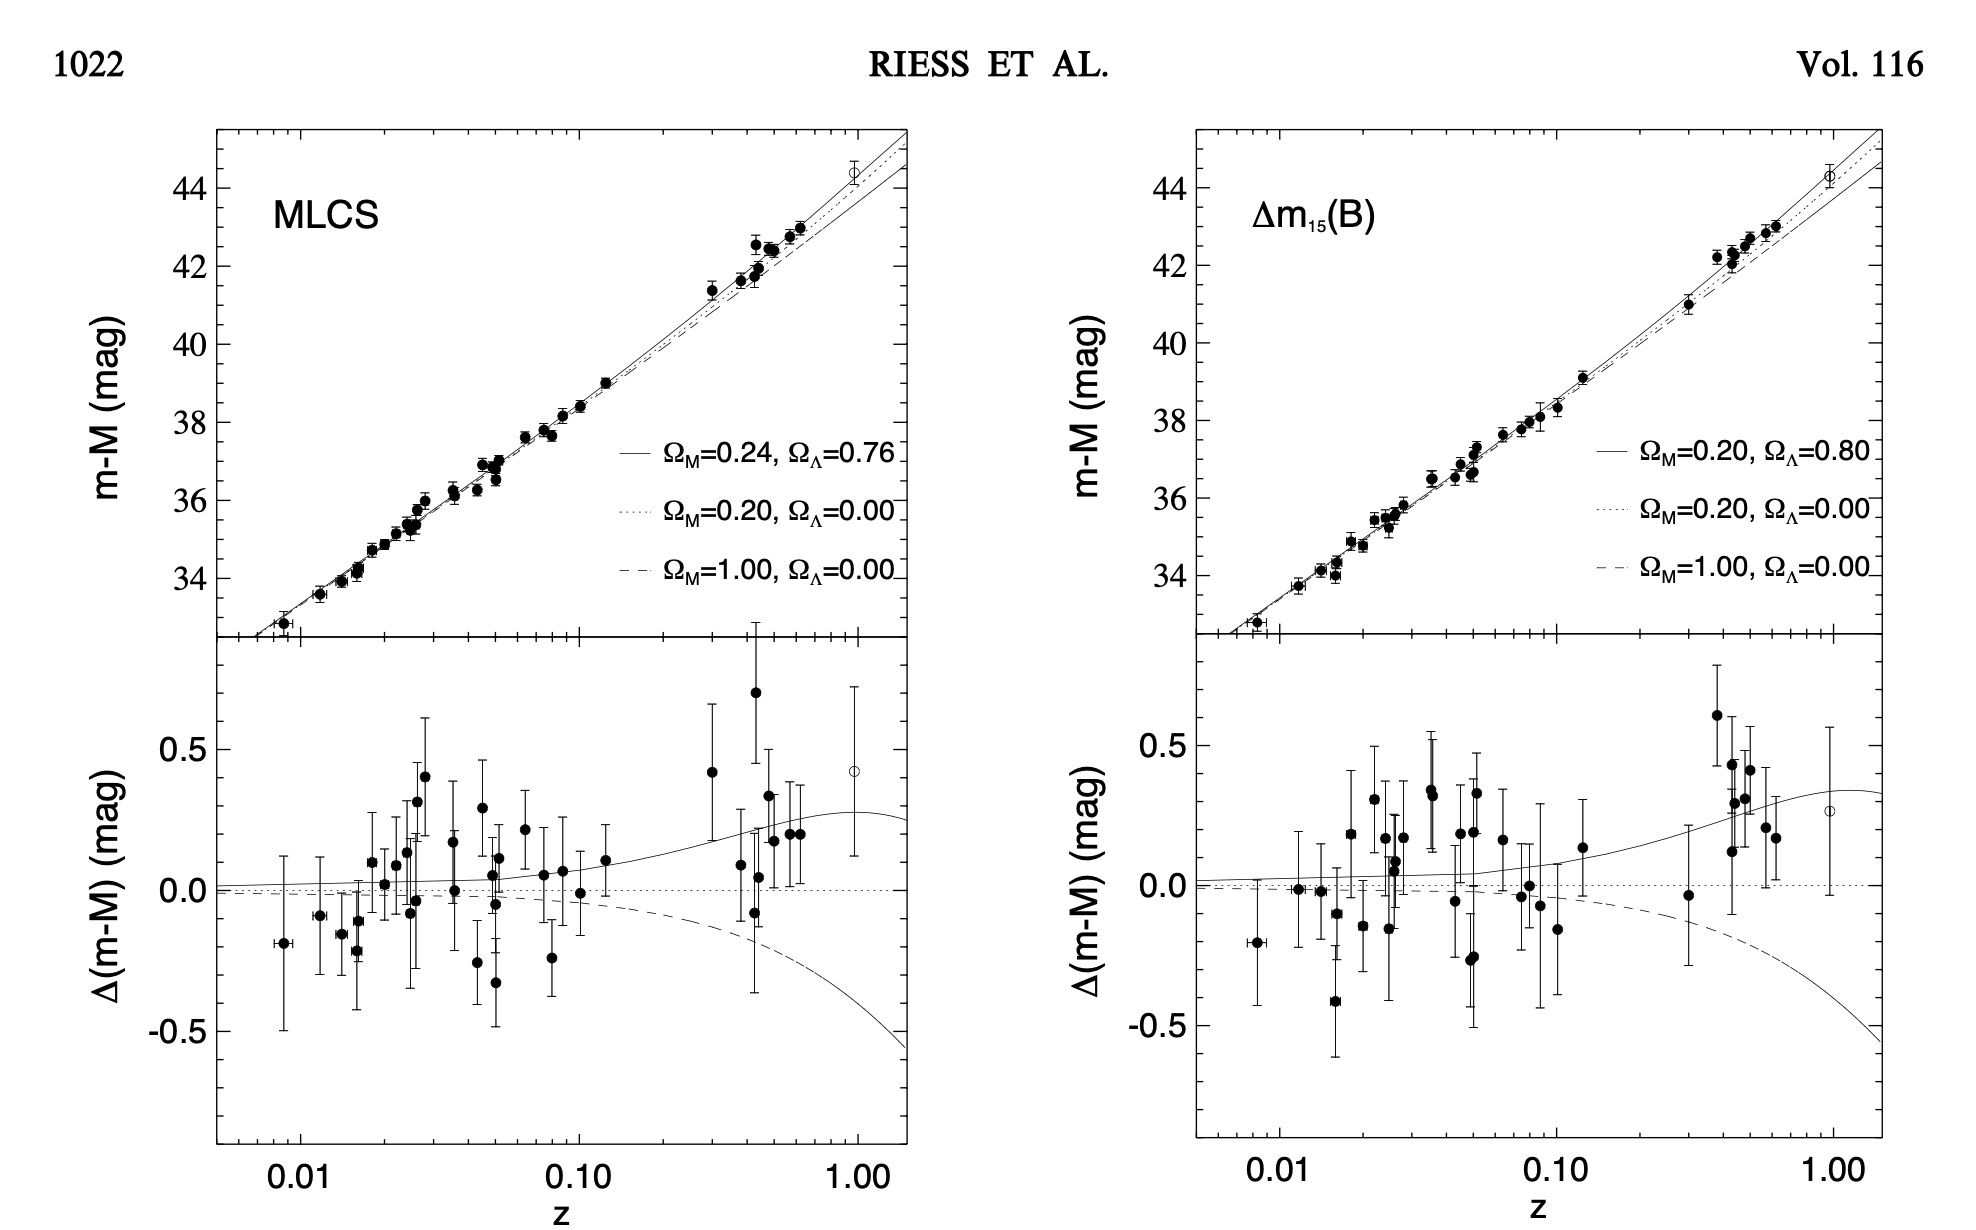

In [8]:
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from astroML.linear_model import PolynomialRegression
from matplotlib.pyplot import get_cmap
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson

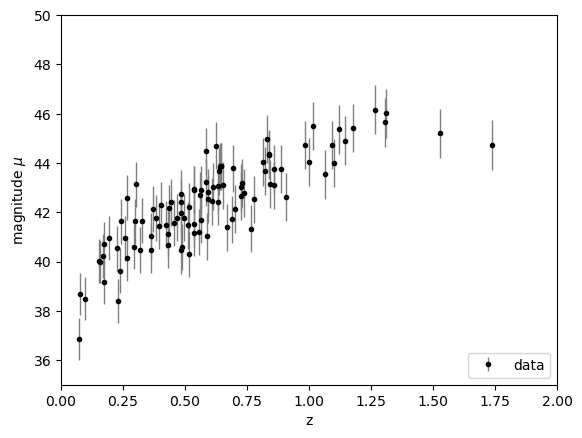

In [9]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"magnitude $\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

**Tasks**

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

**OPTIONAL**

Repeat with Basis Function Regression and Kernel Regression.\
Explore what happens when you change the number of datapoints and plot the resulting learning curves.


**Fisrt of all: I fit the data with the standard cosmological model : $\Lambda$CDM**

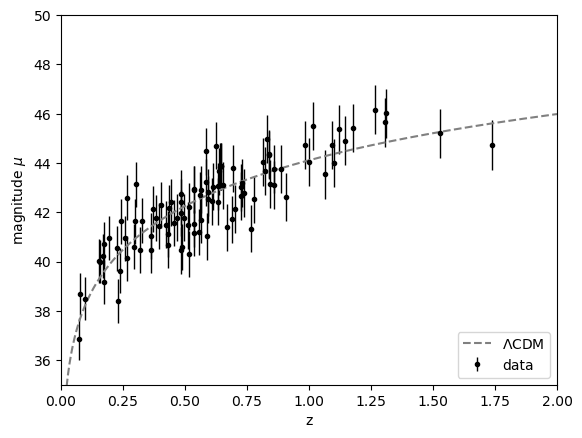

In [10]:
# Cosmological model: Lambda-CDM
from astropy.cosmology import LambdaCDM

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z_true = np.linspace(0.01, 2, 1000)  
mu_true = cosmo.distmod(z_true).value

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='black', lw=1,label='data')
plt.plot(z_true, mu_true, '--', c='grey',label=r"$\Lambda$CDM")
plt.xlabel("z")
plt.ylabel(r"magnitude $\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

## Linear Regression
(with Scikit-Learn)

In [11]:
z = z_sample[:, np.newaxis] 
mu = mu_sample

z_plot = np.linspace(0, 2, 1000)[:, np.newaxis]

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(z, mu, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
mu_pred = lin_reg.predict(z_plot)

39.56505554722625 [4.64711848]


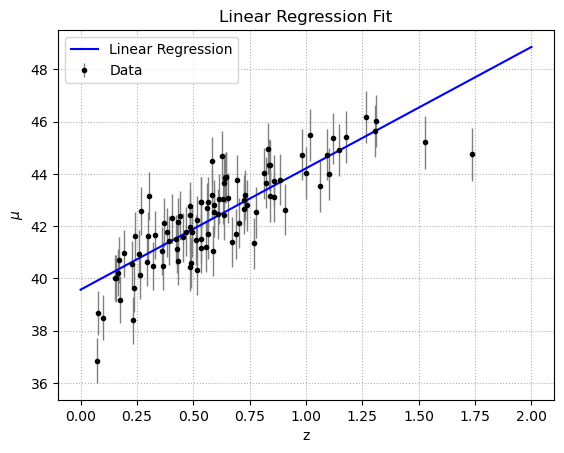

In [13]:
# Plot
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Data')
plt.plot(z_plot, mu_pred, c='blue', label='Linear Regression')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend()
plt.grid(linestyle=':')
plt.title("Linear Regression Fit")
plt.show()

Scikit-Learn's LinearRegression routine does not explicitly account for heteroscedastic error. \
So we can try also using **astroML.linear_model.LinearRegression**

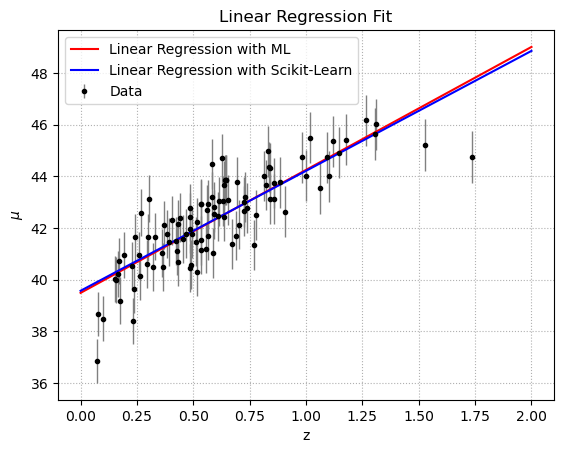

In [14]:
from astroML.linear_model import LinearRegression

lin_reg_ML = LinearRegression()
lin_reg_ML.fit(z, mu, dmu)
mu_pred_ML = lin_reg_ML.predict(z_plot)

# Plot
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Data')
plt.plot(z_plot, mu_pred_ML, c='red', label='Linear Regression with ML')
plt.plot(z_plot, mu_pred, c='blue', label='Linear Regression with Scikit-Learn')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend()
plt.grid(linestyle=':')
plt.title("Linear Regression Fit")
plt.show()

The 2 fits look very similar. But in both cases the linear regression underfits the data... Let's try with a **polynomial regression**

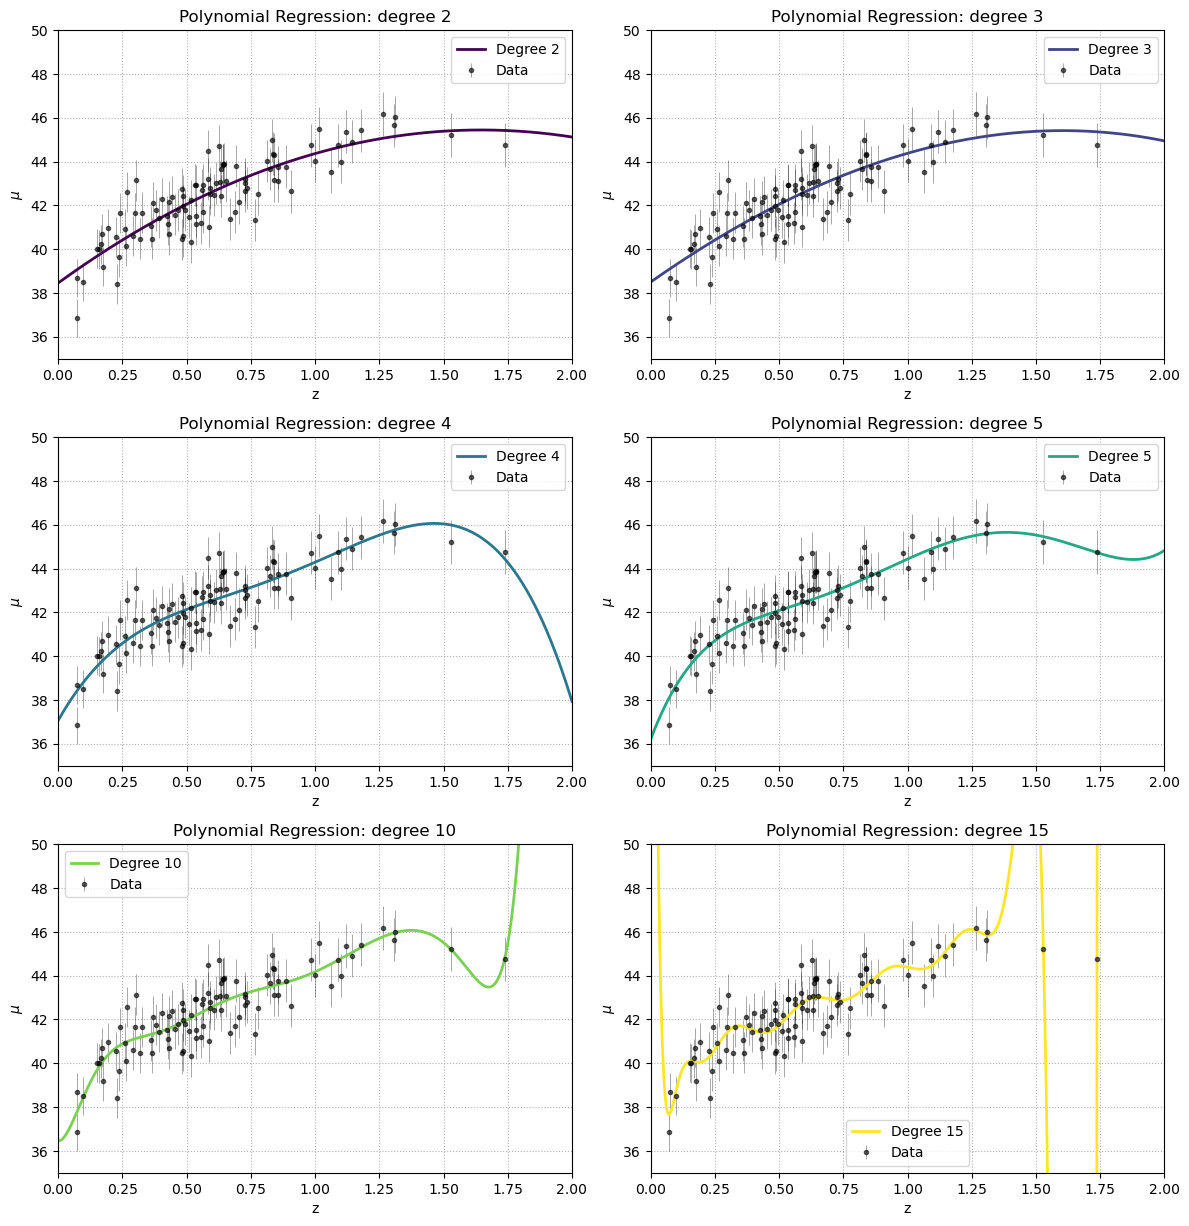

In [15]:
degrees = [2, 3, 4, 5, 10, 15]
colors = get_cmap('viridis')(np.linspace(0, 1, len(degrees)))

plt.figure(figsize=(12, 16))

for i, (d,color) in enumerate(zip(degrees,colors), 1):
    model = PolynomialRegression(d)
    model.fit(z, mu)
    y_plot = model.predict(z_plot)
    
    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', alpha=0.6, lw=0.4, label='Data')
    plt.plot(z_plot, y_plot, label=f'Degree {d}', color = color, linewidth=2)
    plt.xlabel("z")
    plt.ylabel(r"$\mu$")
    plt.xlim(0,2)
    plt.ylim(35, 50)
    plt.title(f"Polynomial Regression: degree {d}")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()

- Degrees 2 and 3 seem to capture the underlying distribution quite well.
- Higher degrees show signs of overfitting, creating unrealistic oscillations that don’t reflect the expected cosmological distribution.

## Basis function regression

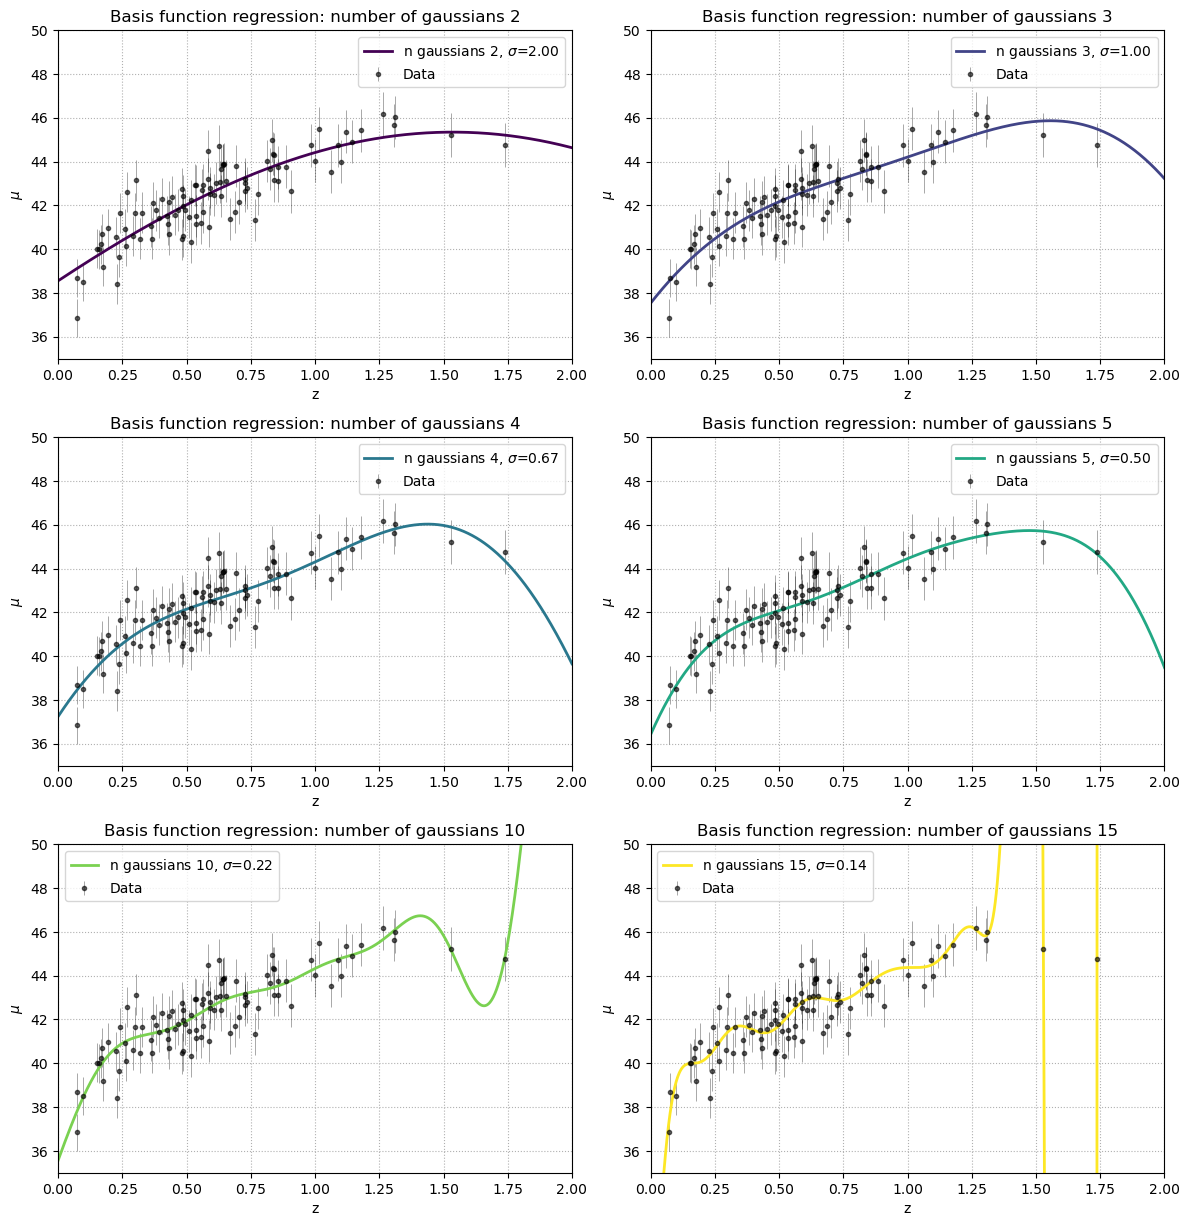

In [16]:
gaussians = [2, 3, 4, 5, 10, 15]
colors = get_cmap('viridis')(np.linspace(0, 1, len(gaussians)))

plt.figure(figsize=(12, 16))

for i, (gauss,color) in enumerate(zip(gaussians,colors), 1):
    mu_test = np.linspace(0, 2, gauss)[:, None]
    sigma_test = 2.0 / (gauss - 1)
    model = BasisFunctionRegression('gaussian', mu=mu_test, sigma=sigma_test)
    model.fit(z, mu, dmu)
    
    y_plot = model.predict(z_plot)
    
    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', alpha=0.6, lw=0.4, label='Data')
    plt.plot(z_plot, y_plot, label=rf'n gaussians {gauss}, $\sigma$={sigma_test:.2f}', color = color, linewidth=2)
    plt.xlabel("z")
    plt.ylabel(r"$\mu$")
    plt.xlim(0,2)
    plt.ylim(35, 50)
    plt.title(f"Basis function regression: number of gaussians {gauss}")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()

Again, at higher degree we can observe overfitting.

## Kernel Regression

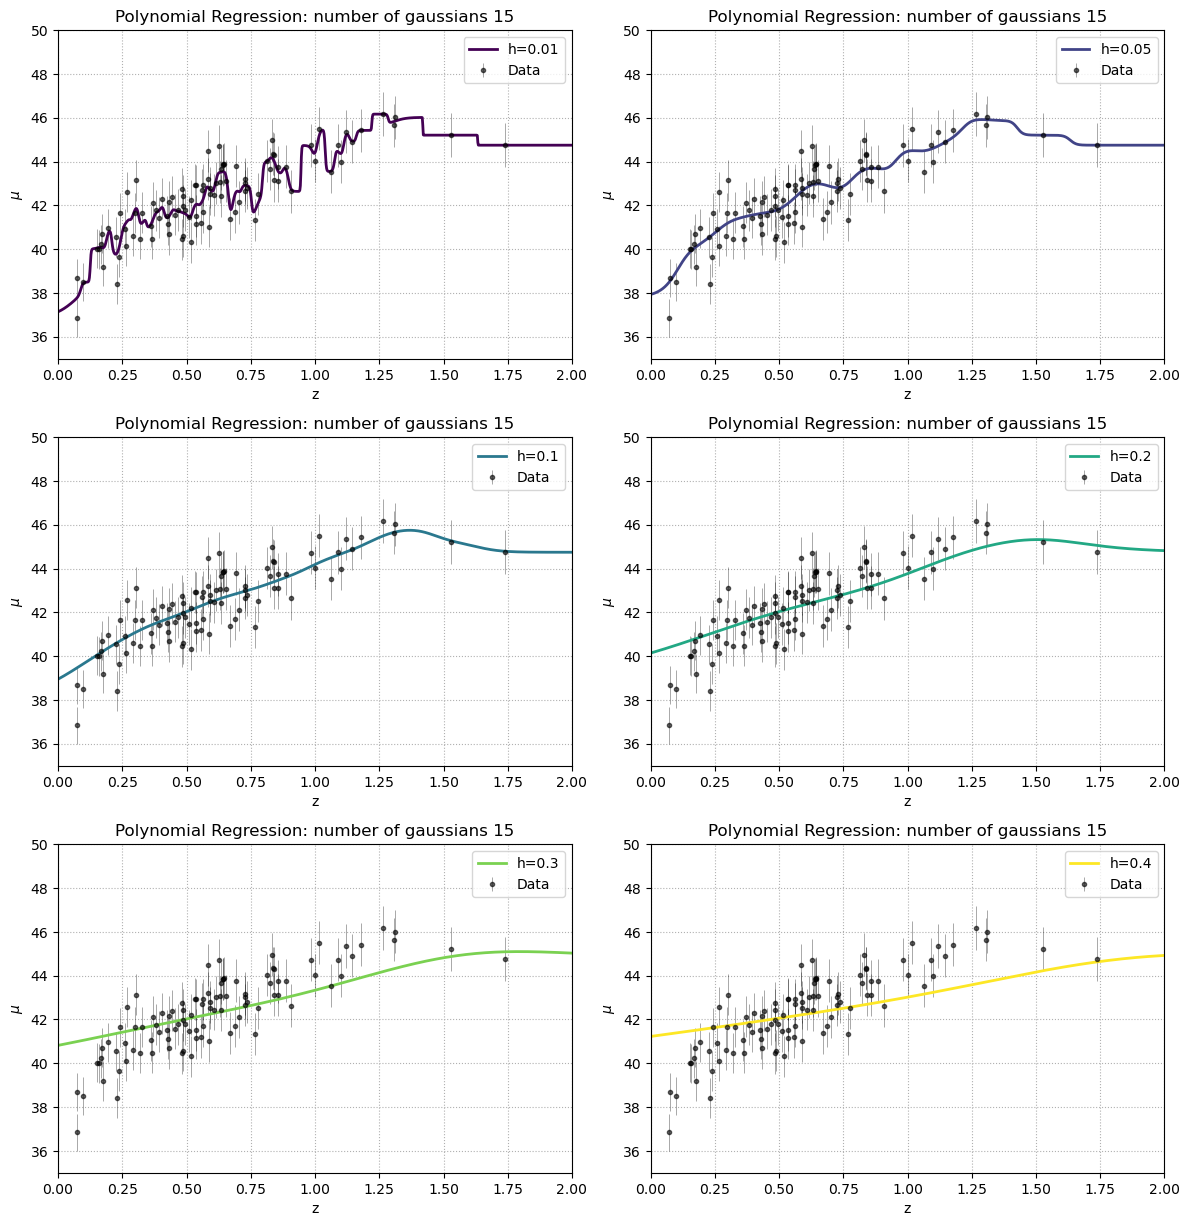

In [17]:
bandwidths = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
colors = get_cmap('viridis')(np.linspace(0, 1, len(bandwidths)))

plt.figure(figsize=(12, 16))

for i, (h,color) in enumerate(zip(bandwidths,colors), 1):
    model = NadarayaWatson('gaussian', h=h)
    model.fit(z, mu, dmu)
    
    y_plot = model.predict(z_plot)
    
    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', alpha=0.6, lw=0.4, label='Data')
    plt.plot(z_plot, y_plot, label=f'h={h}', color = color, linewidth=2)
    plt.xlabel("z")
    plt.ylabel(r"$\mu$")
    plt.xlim(0,2)
    plt.ylim(35, 50)
    plt.title(f"Polynomial Regression: number of gaussians {gauss}")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()

We can observe that too small bandwidths produce overfitting of the data; while too large bandwidths tend to underfit it.

## Cross-validation

In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

## CV Polynomial Regression

Best degree - Polynomial Regression: 2


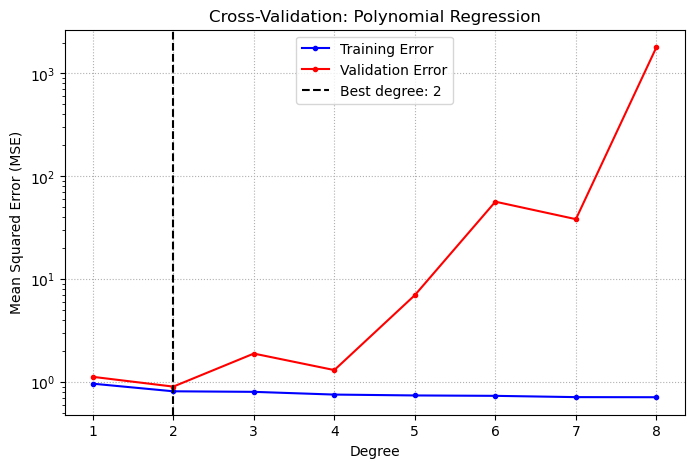

In [19]:
# K-Fold Cross Validation (5 split)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = np.arange(1, 9)
train_err_poly = []
val_err_poly = []

for d in degrees:
    fold_train_err, fold_val_err = [], []
    
    for train_idx, val_idx in kf.split(z):
        z_train, z_val = z[train_idx], z[val_idx]
        mu_train, mu_val = mu[train_idx], mu[val_idx]
        dmu_train, dmu_val = dmu[train_idx], dmu[val_idx]
        
        model = PolynomialRegression(d)
        model.fit(z_train, mu_train, dmu_train)
        
        # Mean Squared Error
        fold_train_err.append(mean_squared_error(mu_train, model.predict(z_train)))
        fold_val_err.append(mean_squared_error(mu_val, model.predict(z_val)))
        
    # Salva la media degli errori sulle K fold
    train_err_poly.append(np.mean(fold_train_err))
    val_err_poly.append(np.mean(fold_val_err))

# Trova il modello migliore (quello con l'errore di validazione minimo)
best_degree = degrees[np.argmin(val_err_poly)]
print(f"Best degree - Polynomial Regression: {best_degree}")

# Plot della curva di errore
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_err_poly, 'b', label='Training Error', marker='.')
plt.plot(degrees, val_err_poly, 'r', label='Validation Error', marker='.')
plt.axvline(best_degree, color='k', linestyle='--', label=f'Best degree: {best_degree}')
plt.yscale('log')
plt.xlabel("Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Cross-Validation: Polynomial Regression")
plt.legend()
plt.grid(linestyle=':')
plt.show()

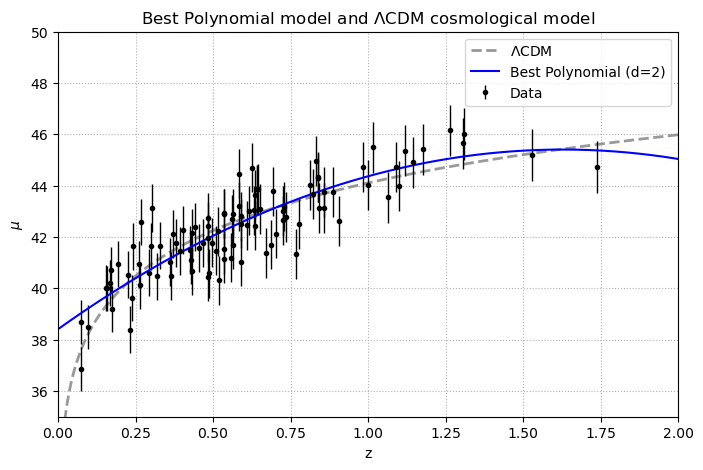

In [20]:
best_poly = PolynomialRegression(best_degree).fit(z, mu, dmu)
y_pred_poly = best_poly.predict(z_plot)

plt.figure(figsize=(8, 5))

plt.plot(z_true, mu_true, '--', c='grey', alpha=0.8, lw=2, label=r"$\Lambda$CDM")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='black', lw=1, label='Data')
plt.plot(z_plot, y_pred_poly, label=f'Best Polynomial (d={best_degree})', color='blue')

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.title(r"Best Polynomial model and $\Lambda$CDM cosmological model")
plt.legend()
plt.grid(linestyle=':')
plt.show()

## CV: Basis function regression

Miglior numero di gaussiane per Basis Function: 2


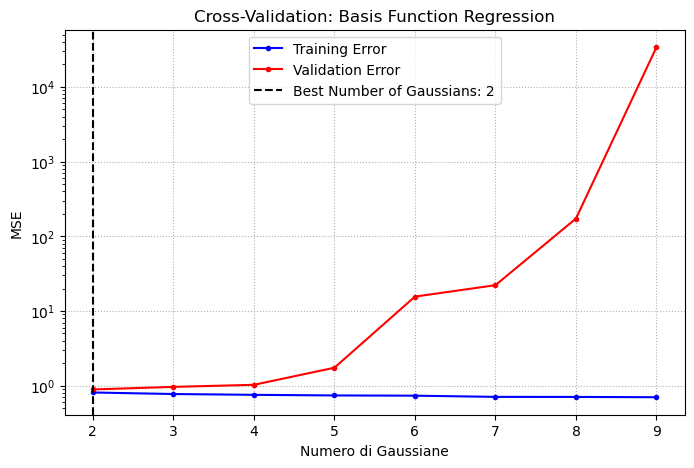

In [21]:
gaussians = np.arange(2, 10)
train_err_bf = []
val_err_bf = []

for gauss in gaussians:
    fold_train_err, fold_val_err = [], []
    
    for train_idx, val_idx in kf.split(z):
        z_train, z_val = z[train_idx], z[val_idx]
        mu_train, mu_val = mu[train_idx], mu[val_idx]
        dmu_train, dmu_val = dmu[train_idx], dmu[val_idx]
        
        # Parametri per le gaussiane (ugualmente spaziate)
        mu_test = np.linspace(0, 2, gauss)[:, None]
        sigma_test = 2.0 / (gauss - 1)
        
        model = BasisFunctionRegression('gaussian', mu=mu_test, sigma=sigma_test)
        model.fit(z_train, mu_train, dmu_train)
        
        fold_train_err.append(mean_squared_error(mu_train, model.predict(z_train)))
        fold_val_err.append(mean_squared_error(mu_val, model.predict(z_val)))
        
    train_err_bf.append(np.mean(fold_train_err))
    val_err_bf.append(np.mean(fold_val_err))

best_gauss = gaussians[np.argmin(val_err_bf)]
print(f"Miglior numero di gaussiane per Basis Function: {best_gauss}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(gaussians, train_err_bf, 'b', label='Training Error', marker='.')
plt.plot(gaussians, val_err_bf, 'red', label='Validation Error', marker='.')
plt.axvline(best_gauss, color='k', linestyle='--', label=f'Best Number of Gaussians: {best_gauss}')
plt.yscale('log')
plt.xlabel("Numero di Gaussiane")
plt.ylabel("MSE")
plt.title("Cross-Validation: Basis Function Regression")
plt.legend()
plt.grid(linestyle=':')
plt.show()

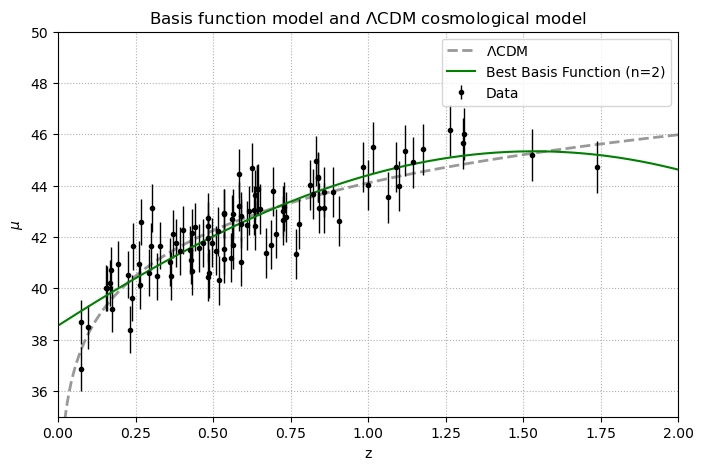

In [22]:
mu_test_best = np.linspace(0, 2, best_gauss)[:, None]
sigma_test_best = 2.0 / (best_gauss - 1)
best_bf = BasisFunctionRegression('gaussian', mu=mu_test_best, sigma=sigma_test_best).fit(z, mu, dmu)

y_pred_bf = best_bf.predict(z_plot)

plt.figure(figsize=(8, 5))
plt.plot(z_true, mu_true, '--', c='grey', lw=2, alpha=0.8, label=r"$\Lambda$CDM")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='black', lw=1, alpha=1, label='Data')
plt.plot(z_plot, y_pred_bf, label=f'Best Basis Function (n={best_gauss})', color='green')

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.title(r"Basis function model and $\Lambda$CDM cosmological model")
plt.legend()
plt.grid(linestyle=':')
plt.show()

## CV: Kernel Regression

Miglior bandwidth per Nadaraya-Watson: 0.0362


/opt/anaconda3/lib/python3.13/site-packages/astroML/linear_model/kernel_regression.py:52: RuntimeWarning: invalid value encountered in divide
  return (K * self.y).sum(1) / K.sum(1)


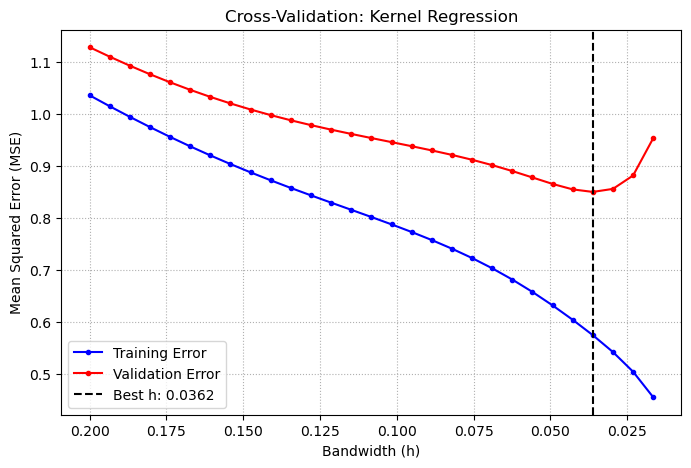

In [24]:
import warnings

# Range di bandwidth
bandwidths = np.linspace(0.01, 0.2, 30)
train_err_nw = []
val_err_nw = []

for h in bandwidths:
    fold_train_err, fold_val_err = [], []
    
    for train_idx, val_idx in kf.split(z):
        z_train, z_val = z[train_idx], z[val_idx]
        mu_train, mu_val = mu[train_idx], mu[val_idx]
        dmu_train, dmu_val = dmu[train_idx], dmu[val_idx]
        
        # Fit del modello
        model = NadarayaWatson('gaussian', h=h)
        model.fit(z_train, mu_train, dmu_train)
        
        # Previsioni
        y_pred_train = model.predict(z_train)
        y_pred_val = model.predict(z_val)
        
        # Gestione dei NaN (se h è troppo piccolo e genera 0/0)
        if np.any(np.isnan(y_pred_train)):
            fold_train_err.append(np.inf)
        else:
            fold_train_err.append(mean_squared_error(mu_train, y_pred_train))
            
        if np.any(np.isnan(y_pred_val)):
            fold_val_err.append(np.inf) # Penalità: scarta questo modello
        else:
            fold_val_err.append(mean_squared_error(mu_val, y_pred_val))
        
    train_err_nw.append(np.mean(fold_train_err))
    val_err_nw.append(np.mean(fold_val_err))

# Trova la bandwidth migliore ignorando i valori infiniti
valid_indices = [i for i, err in enumerate(val_err_nw) if err != np.inf]

if not valid_indices:
    print("Tutti i modelli hanno generato NaN. Aumenta ulteriormente il range di 'h'.")
else:
    # Cerchiamo il minimo solo tra i risultati validi
    best_h = bandwidths[valid_indices[np.argmin(np.array(val_err_nw)[valid_indices])]]
    print(f"Miglior bandwidth per Nadaraya-Watson: {best_h:.4f}")

    # Plot (asse x in scala logaritmica)
    plt.figure(figsize=(8, 5))
    
    # Filtriamo fuori gli np.inf per evitare che il grafico si "schiacci"
    plot_bandwidths = [bandwidths[i] for i in valid_indices]
    plot_train_err = [train_err_nw[i] for i in valid_indices]
    plot_val_err = [val_err_nw[i] for i in valid_indices]
    
    plt.plot(plot_bandwidths, plot_train_err, 'b', label='Training Error', marker='.')
    plt.plot(plot_bandwidths, plot_val_err, 'r', label='Validation Error', marker='.')
    plt.axvline(best_h, color='k', linestyle='--', label=f'Best h: {best_h:.4f}')
    
    #plt.xscale('log')
    plt.xlabel("Bandwidth (h)")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title("Cross-Validation: Kernel Regression")
    plt.legend()
    plt.grid(linestyle=':')
    plt.gca().invert_xaxis()
    plt.show()

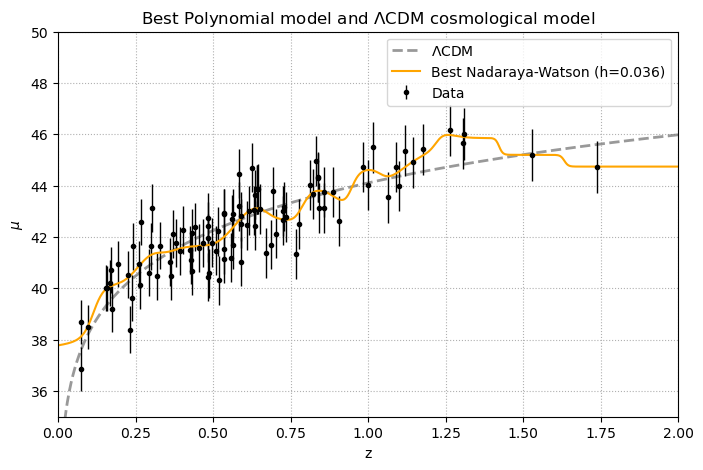

In [25]:
best_nw = NadarayaWatson('gaussian', h=best_h).fit(z, mu, dmu)
y_pred_nw = best_nw.predict(z_plot)

plt.figure(figsize=(8, 5))
plt.plot(z_true, mu_true, '--', c='grey', lw=2, alpha=0.8, label=r"$\Lambda$CDM")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='black', lw=1, alpha=1, label='Data')
plt.plot(z_plot, y_pred_nw, label=f'Best Nadaraya-Watson (h={best_h:.3f})', color='orange')

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.title(r"Best Polynomial model and $\Lambda$CDM cosmological model")
plt.legend()
plt.grid(linestyle=':')
plt.show()

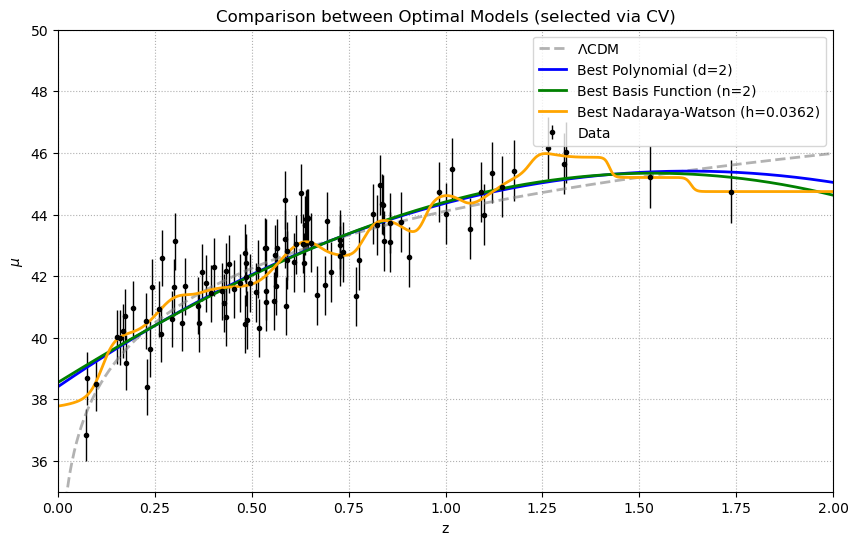

In [26]:
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='black', lw=1, label='Data')

plt.plot(z_true, mu_true, '--', c='grey', alpha=0.6, lw=2, label=r"$\Lambda$CDM")

plt.plot(z_plot, y_pred_poly, label=f'Best Polynomial (d={best_degree})', color='blue', lw=2)
plt.plot(z_plot, y_pred_bf, label=f'Best Basis Function (n={best_gauss})', color='green', lw=2)
plt.plot(z_plot, y_pred_nw, label=f'Best Nadaraya-Watson (h={best_h:.4f})', color='orange', lw=2)

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.title("Comparison between Optimal Models (selected via CV)")
plt.legend()
plt.grid(linestyle=':')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/astroML/linear_model/kernel_regression.py:52: RuntimeWarning: invalid value encountered in divide
  return (K * self.y).sum(1) / K.sum(1)
/opt/anaconda3/lib/python3.13/site-packages/astroML/linear_model/kernel_regression.py:52: RuntimeWarning: invalid value encountered in divide
  return (K * self.y).sum(1) / K.sum(1)


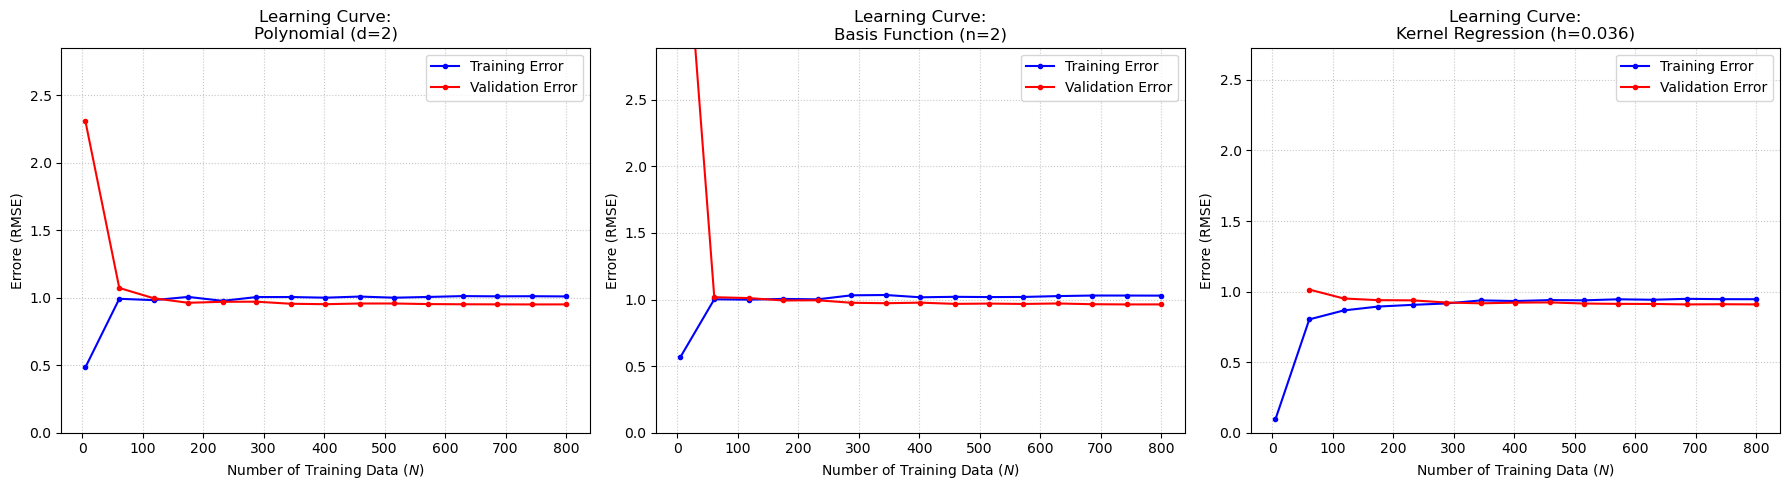

In [27]:
from sklearn.model_selection import train_test_split

# resample
z_resample, mu_resample, dmu_r = generate_mu_z(1000, random_state=1234)
z_resample = z_resample[:, np.newaxis]

# Teniamo il 20% (20 punti) bloccati come banco di prova finale
X_train_pool, X_val, y_train_pool, y_val, dy_train_pool, dy_val = train_test_split(
    z_resample, mu_resample, dmu_r, test_size=0.2, random_state=123
)

def calc_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Learning Curves
# n_trials = number of number of random draws for each dimension
def compute_learning_curve(model, X_t_pool, y_t_pool, dy_t_pool, X_v, y_v, sizes, n_trials=10):
    
    train_errors = []
    cv_errors = []
    
    for size in sizes:
        err_t_trials, err_cv_trials = [], []
        
        for _ in range(n_trials):
            # Estraiamo casualmente punti dal nostro pool di training
            idx = np.random.choice(len(X_t_pool), size, replace=False)
            X_subset = X_t_pool[idx]
            y_subset = y_t_pool[idx]
            dy_subset = dy_t_pool[idx]
            
            # Addestramento del modello su questo sotto-campione
            model.fit(X_subset, y_subset, dy_subset)
            
            # Salviamo l'errore sul training attuale e sul validation (che è sempre lo stesso!)
            err_t_trials.append(calc_error(y_subset, model.predict(X_subset)))
            err_cv_trials.append(calc_error(y_v, model.predict(X_v)))
            
        train_errors.append(np.mean(err_t_trials))
        cv_errors.append(np.mean(err_cv_trials))
        
    return train_errors, cv_errors

mu_test_best = np.linspace(0, 2, best_gauss)[:, None]
sigma_test_best = 2.0 / (best_gauss - 1)

best_models = {
    f"Polynomial (d={best_degree})": PolynomialRegression(best_degree),
    f"Basis Function (n={best_gauss})": BasisFunctionRegression('gaussian', mu=mu_test_best, sigma=sigma_test_best),
    f"Kernel Regression (h={best_h:.3f})": NadarayaWatson('gaussian', h=best_h)
}

train_sizes = np.linspace(5, len(X_train_pool), 15, dtype=int)

# Plot
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(best_models.items(), 1):
    
    t_err, v_err = compute_learning_curve(
        model, X_train_pool, y_train_pool, dy_train_pool, X_val, y_val, train_sizes, n_trials=15
    )
    
    plt.subplot(1, 3, i)
    plt.plot(train_sizes, t_err, 'b', lw=1.5, label='Training Error', marker='.')
    plt.plot(train_sizes, v_err, 'r', lw=1.5, label='Validation Error', marker='.')
    
    plt.title(f"Learning Curve:\n{name}")
    plt.xlabel("Number of Training Data ($N$)")
    plt.ylabel("Errore (RMSE)")
    
    plt.ylim(0, max(v_err[-1]*3, max(t_err)*1.2)) 
    
    plt.legend()
    plt.grid(linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

- When N_train is very small, the training error is close to zero (because the model "learns" those points easily), but the validation error will be very high.
- As N increases, the two curves become closer.
- When the lines are flat and close together, the model has reached a plateau: adding more data won't change anything!

# L18: Supernova distances and redshifts (part 2)
First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the kernels submodule of sklearn.gaussian_process
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

Note. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

In [29]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel 
from sklearn.model_selection import KFold

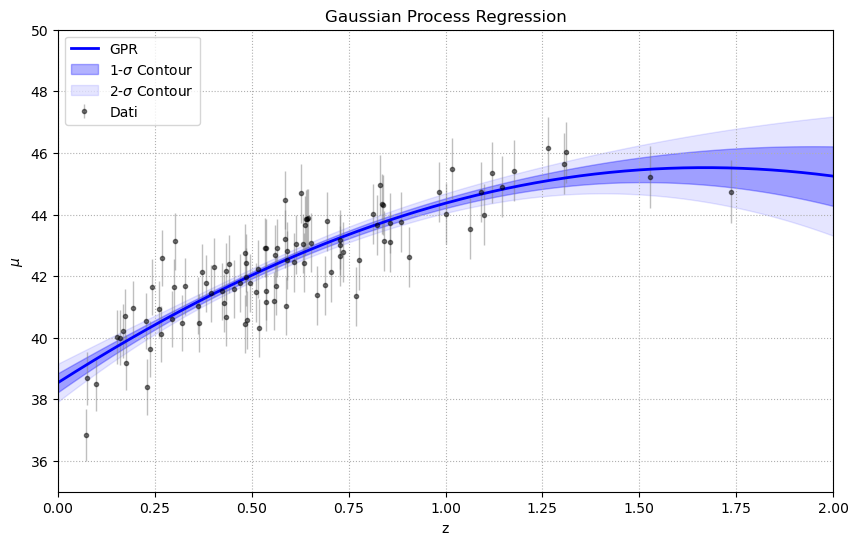

In [30]:
# Kernel
# ConstantKernel = it scales the amplitude (variance) of the curves on the Y-axis 
#  * 0.5 is the intial value for the amplitude
#  * (1e-3, 1e3) are the limits within which to look for the optimal value
# RBF = it controls the "smoothness" of the curve along the X-axis
#  * length_scale = 1.0 is the inital value for the length scale
#  * length_scale_bounds = (1e-2, 1e2) are the limits within which to look for the optimal value

kernel = ConstantKernel(0.5, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) 
gpr = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2)
gpr.fit(z, mu_sample)

#best_constant = gpr.kernel_.k1.constant_value
#best_ls = gpr.kernel_.k2.length_scale

#print(f"L'ampiezza ottimale trovata è: {best_constant:.4f}")
#print(f"La length scale ottimale trovata è: {best_ls:.4f}")

# Plot
z_plot = np.linspace(0, 2, 1000)[:, np.newaxis]
mu_pred_gpr, sigma_pred_gpr = gpr.predict(z_plot, return_std=True) 

plt.figure(figsize=(10, 6))
# original data
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, alpha=0.5, label='Dati')

# Gaussian Process Regression (GPR)
plt.plot(z_plot, mu_pred_gpr, 'b-', lw=2, label='GPR')

# 1-sigma and 2-sigma contours
plt.fill_between(z_plot.ravel(), mu_pred_gpr - sigma_pred_gpr, mu_pred_gpr + sigma_pred_gpr, 
                 color='blue', alpha=0.3, label=r'1-$\sigma$ Contour')
plt.fill_between(z_plot.ravel(), mu_pred_gpr - 2*sigma_pred_gpr, mu_pred_gpr + 2*sigma_pred_gpr, 
                 color='blue', alpha=0.1, label=r'2-$\sigma$ Contour')

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.title(f"Gaussian Process Regression")
plt.legend()
plt.grid(linestyle=':')
plt.show()

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.

- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given.

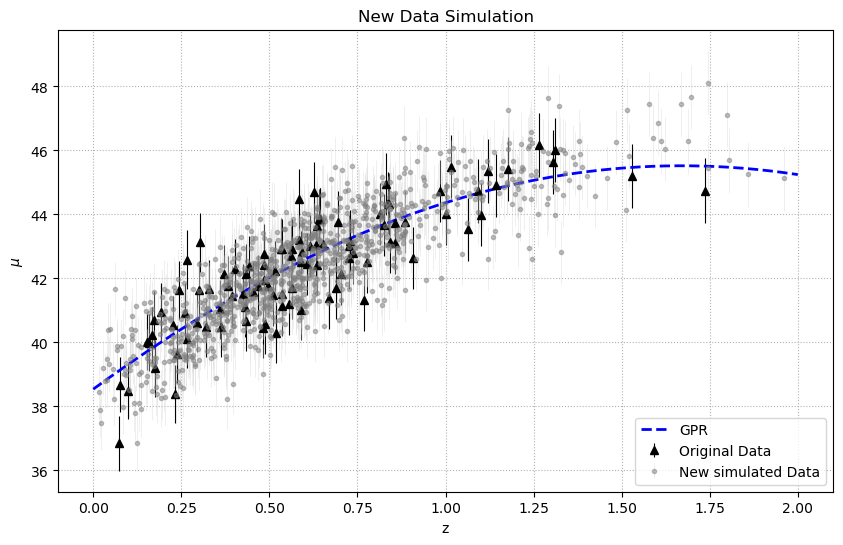

In [31]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(bandwidth=0.1, kernel='gaussian')
kde.fit(z_sample[:, np.newaxis])

# Redshift new values: 2000 new samples, but we take only 1000 between z=0 and z=2 (the range of our original data)
z_new = kde.sample(2000, random_state=42)
z_new = z_new[(z_new > 0.01) & (z_new < 2.0)][:1000].reshape(-1, 1)

# New set of mu measurements using gpr
mu_new = gpr.sample_y(z_new, n_samples=1, random_state=123).ravel()

# Errors on the new sample --> we take the behavior of the original dmu errors as a function of z and apply them to the new data
sort_idx = np.argsort(z_sample)
z_sorted = z_sample[sort_idx]
dmu_sorted = dmu[sort_idx]

dmu_new = np.interp(z_new.ravel(), z_sorted, dmu_sorted)

# mu observed (with simulated errors)
mu_obs = np.random.normal(mu_new, dmu_new)

# Plot
plt.figure(figsize=(10, 6))

# Original Data
plt.errorbar(z_sample, mu_sample, dmu, fmt='^', color='black', ecolor='black', lw=0.8, alpha=1, label='Original Data')

# New Data
plt.errorbar(z_new.ravel(), mu_obs, dmu_new, fmt='.', color='grey',
             ecolor='lightgrey', alpha=0.5, lw=0.5, label='New simulated Data')

# gpr curve
plt.plot(z_plot, mu_pred_gpr, 'b--', lw=2, label='GPR')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.title("New Data Simulation")
plt.legend(loc='lower right')
plt.grid(linestyle=':')
plt.show()

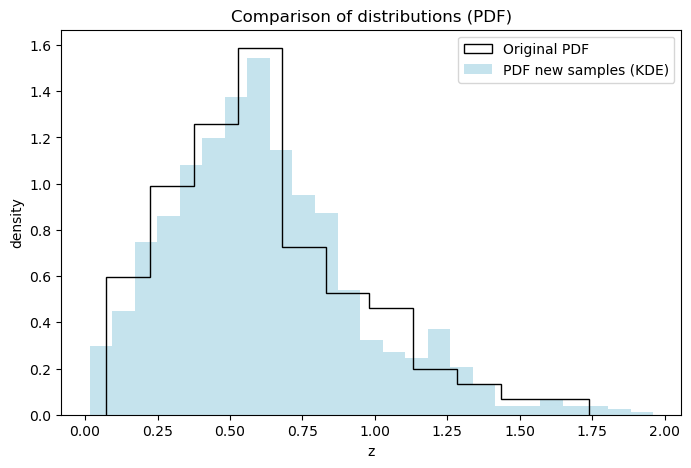

In [32]:
# PDF of original data vs PDF new simulated data
plt.figure(figsize=(8, 5))
plt.hist(z_sample, bins="fd", density=True, color='black', histtype="step", label='Original PDF')
plt.hist(z_new, bins="fd", density=True, alpha=0.7, color='lightblue', label='PDF new samples (KDE)')
plt.title("Comparison of distributions (PDF)")
plt.xlabel("z")
plt.ylabel("density")
plt.legend()
plt.show()

# L18: Supernova distances and redshifts (part 3)
We now have a suite of data-driven predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a parametric fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

1. First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $z$:
$$\mu = 5 \log_{10} \left(\frac{c/H_0}{10 \rm pc} (1+z) \int_{0}^{z} \frac{dz'}{\sqrt{\Omega_m (1+z')^3 + \Omega_\Lambda}} \right)$$
2. Assuming a flat Universe, we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$
 and the matter content of the Universe $\Omega_m$
3. It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
   - Set up a Bayesian framework and use MCMC.
   - Set up a fully-connected neural network (see end of the class).
4. What are the measured value of $H_0$ and $\Omega_m$? What's they errors? Are they correlated?
5. How would a model without dark energy (i.e. $\Omega_m = 1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

## Parametric Fit

In [33]:
from astropy.cosmology import FlatLambdaCDM

# Compute mu(z) given H0 and Omega_m (Omega_Lambda = 1 - Omega_m)
def mu_model_lcdm(z_array, theta):
    H0, Om = theta
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return cosmo.distmod(z_array).value

## Let's fit the data using MCMC

In [34]:
import emcee
import corner

In [35]:
def log_likelihood(theta, z, mu, dmu):
    #H0, Om = theta
    model = mu_model_lcdm(z, theta)
    return -0.5 * np.sum(((mu - model) / dmu)**2)

def log_prior(theta):
    H0, Om = theta
    if 50.0 < H0 < 100.0 and 0.0 <= Om <= 1.0:
        return 0.0
    return -np.inf

def log_posterior(theta, z, mu, dmu):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, dmu)

In [36]:
# Run MCMC with emcee
n_dim = 2  # number of parameters in the model: H0 and Omega_m
n_walkers = 8  # number of MCMC walkers
n_steps = 10000  # number of MCMC steps to take for each walker

initial_guess = [70, 0.3]
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_dim)
print(pos.shape)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(z_sample, mu_sample, dmu))
sampler.run_mcmc(pos, n_steps, progress=True);

(8, 2)


100%|█████████████████████████████████████| 10000/10000 [06:00<00:00, 27.78it/s]


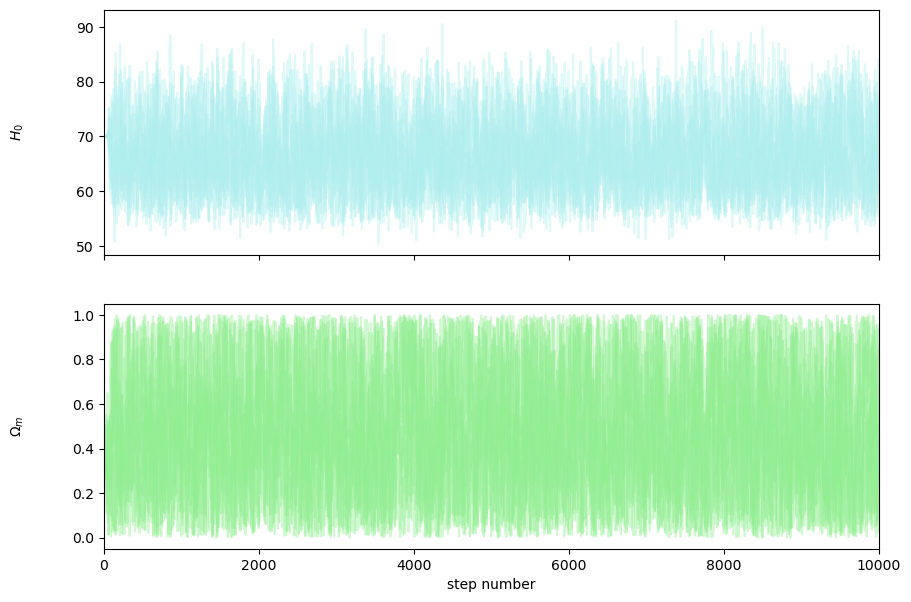

In [37]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = [r"$H_0$", r"$\Omega_{m}$"]
colors = ["paleturquoise", "lightgreen"]
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples[:, :, i], c=colors[i], alpha=0.4)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [38]:
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")
print(f"Max autocorrelation time: {np.max(tau):.1f}")

burnin = int(3 * np.max(tau))
thin = int(np.max(tau))
print(f"Burn-in: {burnin} steps")
print(f"Thinning: every {thin} steps")

flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print(f"Number of independent samples: {flat_samples.shape[0]}")

Autocorrelation times: [39.85129593 40.93865299]
Max autocorrelation time: 40.9
Burn-in: 122 steps
Thinning: every 40 steps
Number of independent samples: 1968


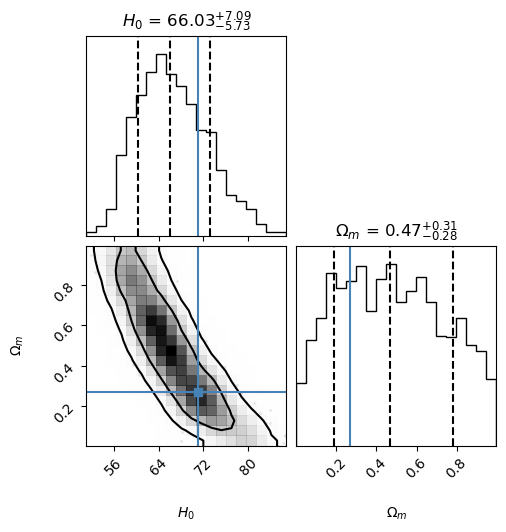

In [39]:
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12},
    levels=(0.68, 0.95),
    plot_contours=True,
    smooth=1.0,
    truths=[71,0.27]
)
plt.show()

In [40]:
H0, Om = np.percentile(flat_samples, 50, axis=0)
H0_err_minus, Om_err_minus = H0 - np.percentile(flat_samples, 16, axis=0)
H0_err_plus, Om_err_plus = np.percentile(flat_samples, 84, axis=0) - H0

corr_matrix = np.corrcoef(flat_samples.T)
corr = corr_matrix[0, 1]

print("\n=== RESULTS (MCMC) ===")
print(f"H0 = {H0:.2f} (+{H0_err_plus:.2f} / -{H0_err_minus:.2f}) km/s/Mpc")
print(f"Omega_m = {Om:.3f} (+{Om_err_plus:.3f} / -{Om_err_minus:.3f})")
print(f"Correlation coefficient between Omega_m and H0 = {corr:.3f}")



=== RESULTS (MCMC) ===
H0 = 66.03 (+7.09 / -5.73) km/s/Mpc
Omega_m = 0.470 (+-65.249 / -65.839)
Correlation coefficient between Omega_m and H0 = -0.870


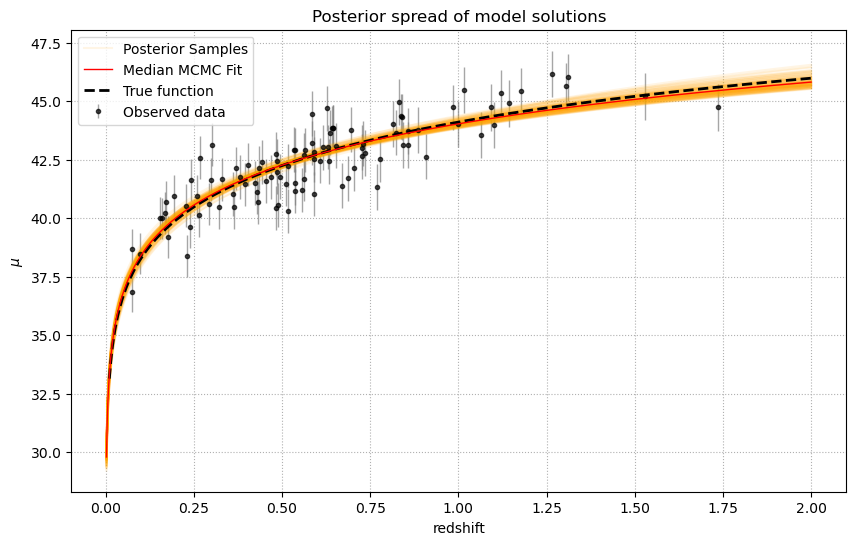

In [42]:
# Plot the Posterior
idx = np.random.choice(len(flat_samples), size=100, replace=False)
random_samples = flat_samples[idx]

plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', alpha=0.7, lw=1, label='Observed data')

for i, theta in enumerate(random_samples):
    y_model = mu_model_lcdm(z_plot, theta)
    label = "Posterior Samples" if i == 0 else None
    plt.plot(z_plot, y_model, color='orange', alpha=0.1, label=label)

plt.plot(z_plot, mu_model_lcdm(z_plot, (H0, Om)), color='red', lw=1, zorder=10, label='Median MCMC Fit')
plt.plot(z_true, mu_true, '--', c='k', label='True function', lw=2)

plt.title("Posterior spread of model solutions")
plt.xlabel("redshift")
plt.ylabel(r"$\mu$")
plt.grid(linestyle=":")
plt.legend()
plt.show()

## Universe without dark energy 

In [43]:
import dynesty
from dynesty import NestedSampler
from dynesty import plotting as dyplot

In [44]:
# No Dark Energy -> only 1 parameter H_0 (Omega_m = 1.0 is fixed)
def mu_model_noDE(z_array, H0):
    return mu_model_lcdm(z_array, (H0, 1.0))


In [45]:
# prior transformation for Nested Sampling
def ptform_lcdm(u): # u is an array of 2 vectors from 0 to 1
    H0 = 50.0 + 50.0 * u[0]  # --> [50, 100]
    Om = 1.0 * u[1]          # --> [0, 1]
    return np.array([H0, Om])

def log_likelihood_noDE(theta, z, mu, dmu):
    H0 = theta[0]
    model = mu_model_noDE(z, H0)
    return -0.5 * np.sum(((mu - model) / dmu)**2)

def ptform_noDE(u):
    H0 = 50.0 + 50.0 * u[0]
    return np.array([H0])

In [46]:
sampler_lcdm = NestedSampler(log_likelihood, ptform_lcdm, ndim=2, logl_args=(z_sample, mu_sample, dmu))
sampler_lcdm.run_nested(dlogz=0.1)

res_lcdm = sampler_lcdm.results
logZ_lcdm = res_lcdm.logz[-1]   # Bayesian Evidence
logZ_lcdm_err = res_lcdm.logzerr[-1]

2288it [01:37, 23.47it/s, +500 | bound: 2 | nc: 1 | ncall: 19621 | eff(%): 14.581 | loglstar:   -inf < -46.385 <    inf | logz: -48.608 +/-  0.052 | dlogz:  0.000 >  0.100]


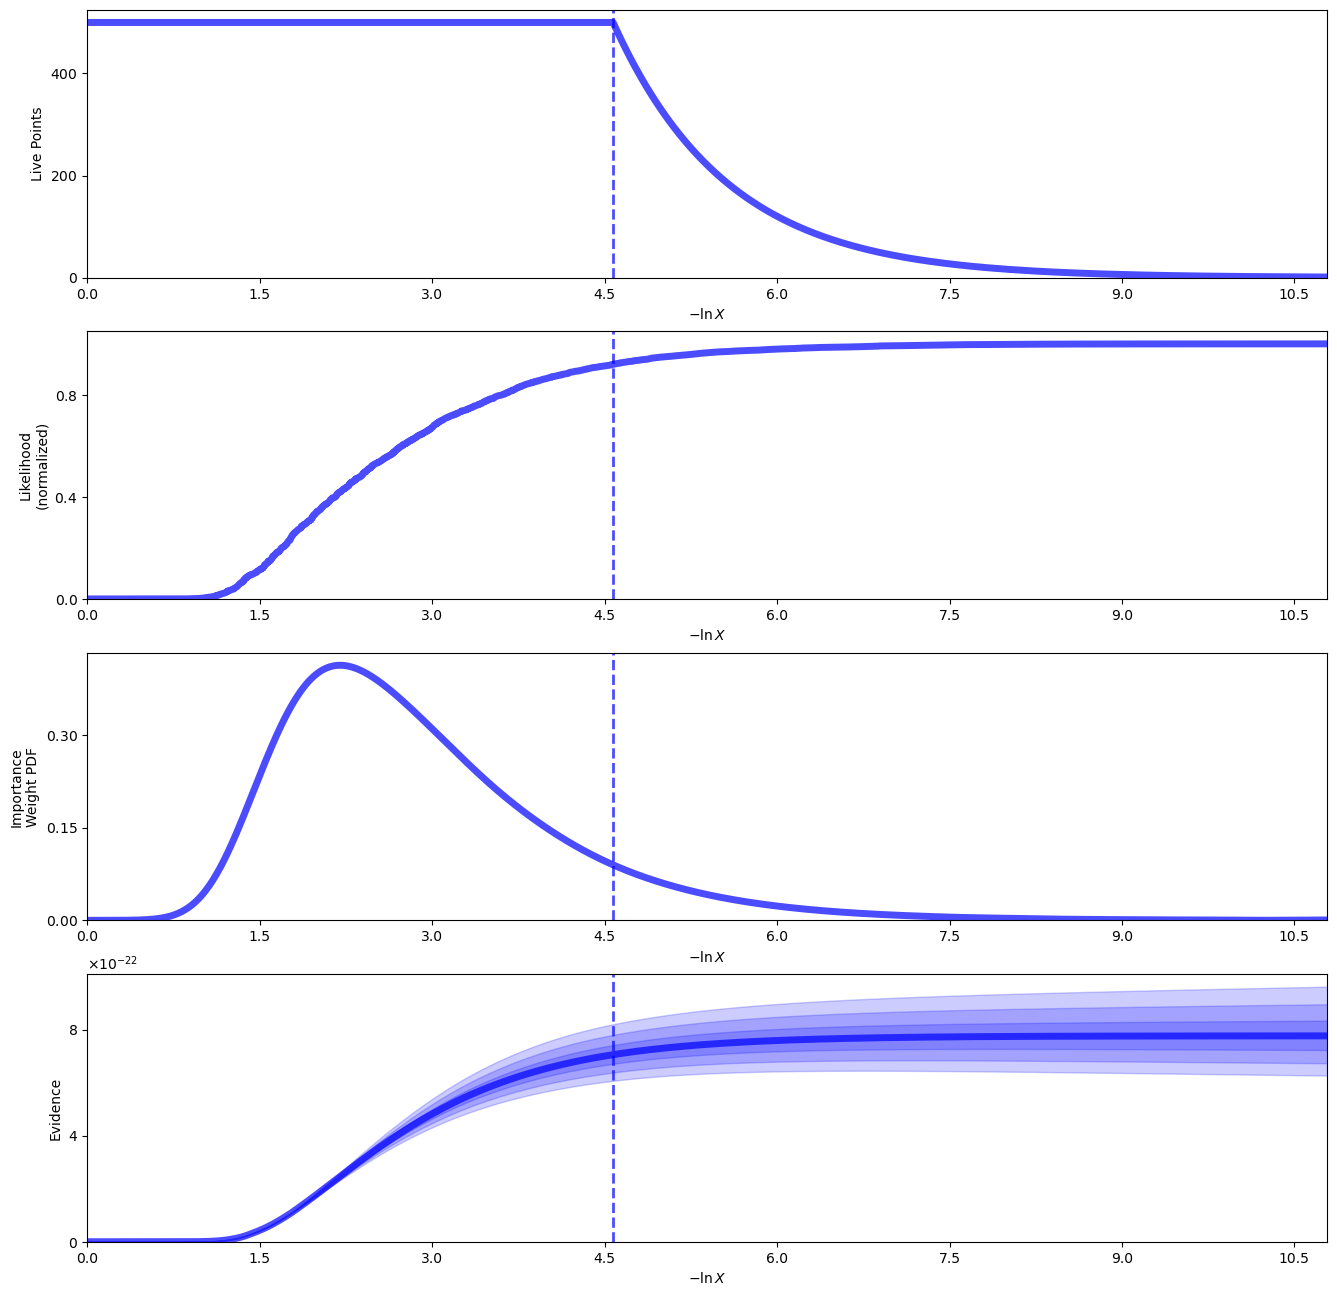

In [47]:
rfig, raxes = dyplot.runplot(res_lcdm)

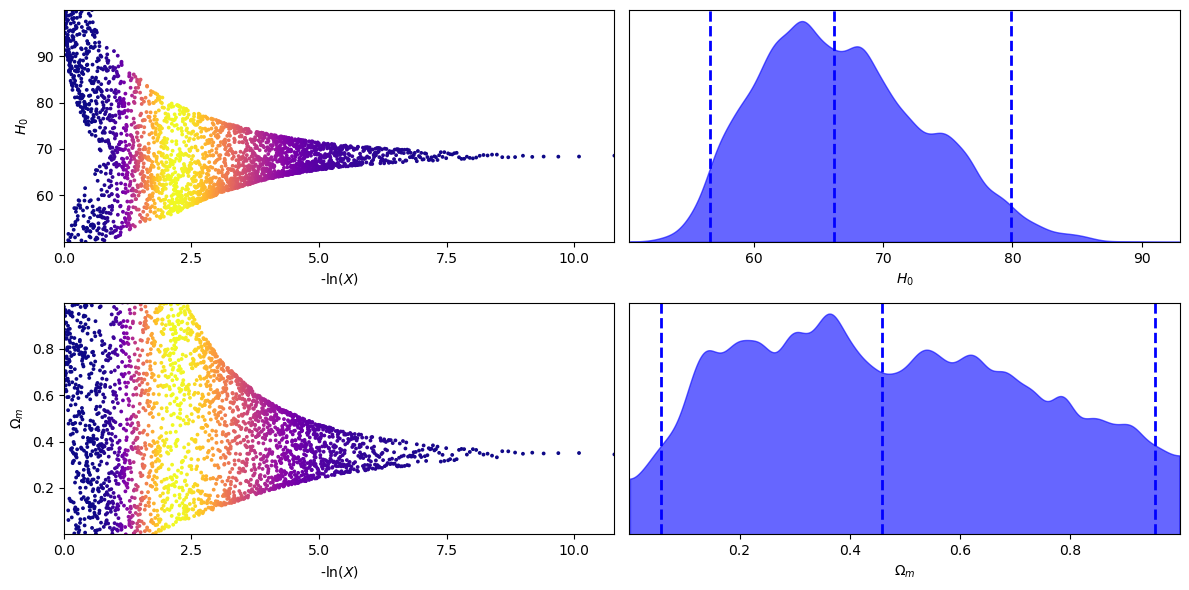

In [48]:
tfig, taxes = dyplot.traceplot(res_lcdm, trace_cmap='plasma', trace_color=None)
taxes[0][0].set_xlabel(r"-$\ln(X)$")
taxes[1][0].set_ylabel(r"$\Omega_{m}$")
taxes[1][1].set_xlabel(r"$\Omega_{m}$")

taxes[1][0].set_xlabel(r"-$\ln(X)$")
taxes[0][0].set_ylabel(r"$H_0$")
taxes[0][1].set_xlabel(r"$H_0$")

tfig.tight_layout()

In [49]:
sampler_noDE = dynesty.NestedSampler(log_likelihood_noDE, ptform_noDE, ndim=1, logl_args=(z_sample, mu_sample, dmu))
sampler_noDE.run_nested(dlogz=0.1)
res_noDE = sampler_noDE.results
logZ_noDE = res_noDE.logz[-1] # Bayesian Evidence
logZ_noDE_err = res_noDE.logzerr[-1]

2197it [01:36, 22.82it/s, +500 | bound: 2 | nc: 1 | ncall: 19102 | eff(%): 14.498 | loglstar:   -inf < -47.102 <    inf | logz: -49.140 +/-  0.051 | dlogz:  0.000 >  0.100]


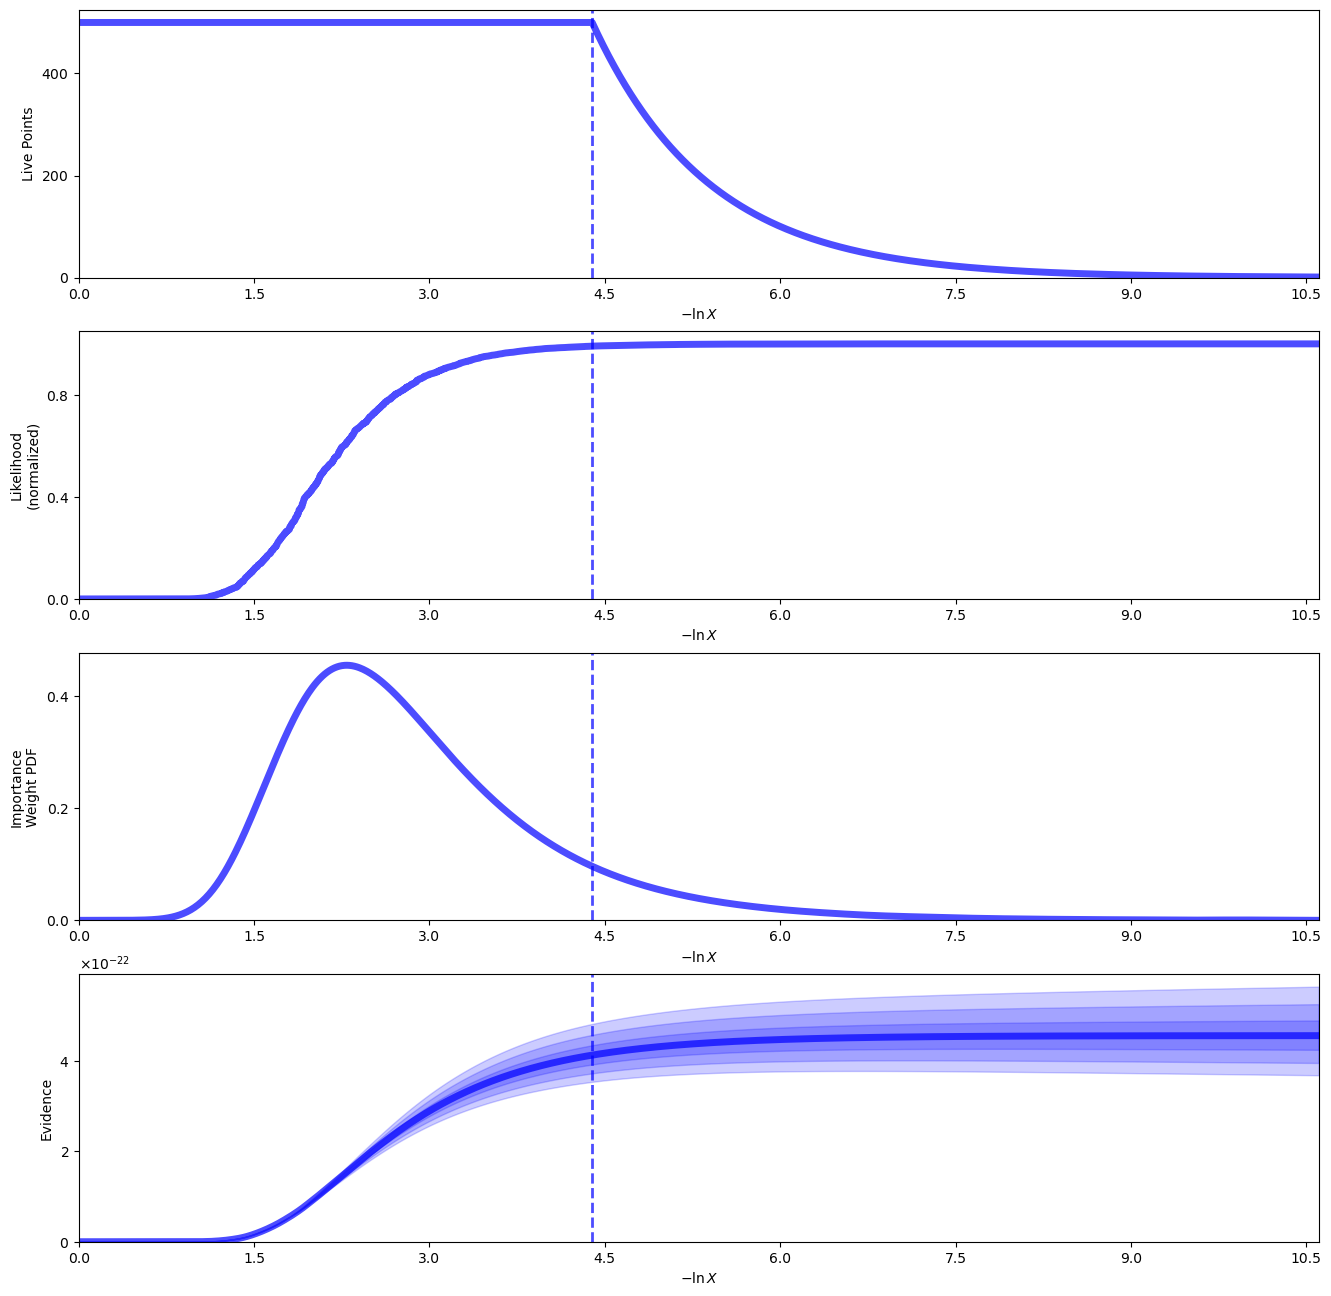

In [50]:
rfig, raxes = dyplot.runplot(res_noDE)

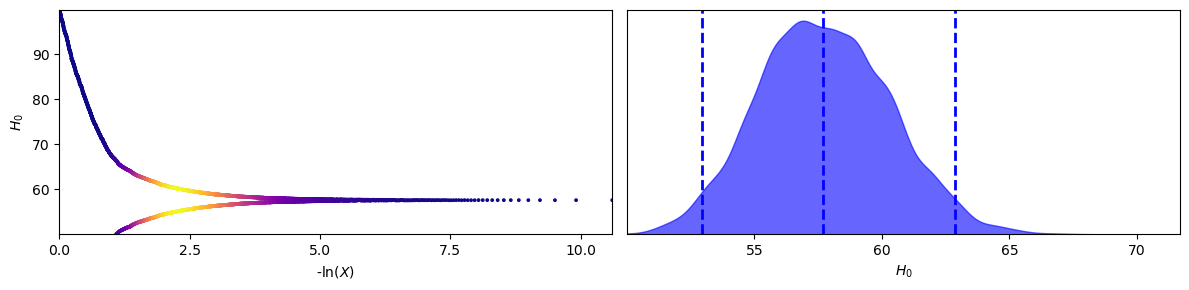

In [51]:
tfig, taxes = dyplot.traceplot(res_noDE, trace_cmap='plasma', trace_color=None)
taxes[0][0].set_xlabel(r"-$\ln(X)$")
taxes[0][0].set_ylabel(r"$H_0$")
taxes[0][1].set_xlabel(r"$H_0$")

tfig.tight_layout()

In [52]:
from dynesty import utils as dyfunc

samples_noDE = res_noDE.samples
weights_noDE = np.exp(res_noDE.logwt - res_noDE.logz[-1])

samples_lcdm = res_lcdm.samples
weights_lcdm = np.exp(res_lcdm.logwt - res_lcdm.logz[-1])

mean_lcdm, cov_lcdm = dyfunc.mean_and_cov(samples_lcdm, weights_lcdm)
H0_mean_lcdm = mean_lcdm[0]
H0_std_lcdm = np.sqrt(cov_lcdm[0, 0])
Om_mean_lcdm = mean_lcdm[1]
Om_std_lcdm = np.sqrt(cov_lcdm[1, 1])
print("========= LambdaCDM =========")
print(f"Omega Matter : {Om_mean_lcdm:.2f} ± {Om_std_lcdm:.2f}")
print(f"H0 : {H0_mean_lcdm:.2f} ± {H0_std_lcdm:.2f} km/s/Mpc")
print("\n")

mean_noDE, cov_noDE = dyfunc.mean_and_cov(samples_noDE, weights_noDE)
H0_mean = mean_noDE[0]
H0_std = np.sqrt(cov_noDE[0, 0])
print("========= No Dark Matter =========")
print("Omega Matter = 1")
print(f"H0 : {H0_mean:.2f} ± {H0_std:.2f} km/s/Mpc")
print("\n")

========= LambdaCDM =========
Omega Matter : 0.48 ± 0.26
H0 : 66.82 ± 6.33 km/s/Mpc


========= No Dark Matter =========
Omega Matter = 1
H0 : 57.74 ± 2.56 km/s/Mpc




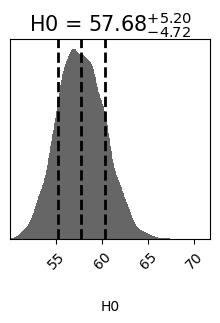

In [53]:
fig, axes = dyplot.cornerplot(res_noDE, labels=["H0"], quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 15},)
plt.show()

## Bayes Factor

In [54]:
# Bayes Factor: B  = Z_lcdm / Z_node
delta_logZ = logZ_lcdm - logZ_noDE
B = np.exp(logZ_lcdm) / np.exp(logZ_noDE)

print(f"Evidence Lambda-CDM :  {np.exp(logZ_lcdm)}")
print(f"Evidence No-Dark-Energy : {np.exp(logZ_noDE)}")
print(f"Bayes Factor: {B:.2f}")

Evidence Lambda-CDM :  7.760136829221583e-22
Evidence No-Dark-Energy : 4.558189233884771e-22
Bayes Factor: 1.70


**This Bayes factor is inconclusive. We cannot conclude from this data whether we live in a universe that contains dark energy or not.**

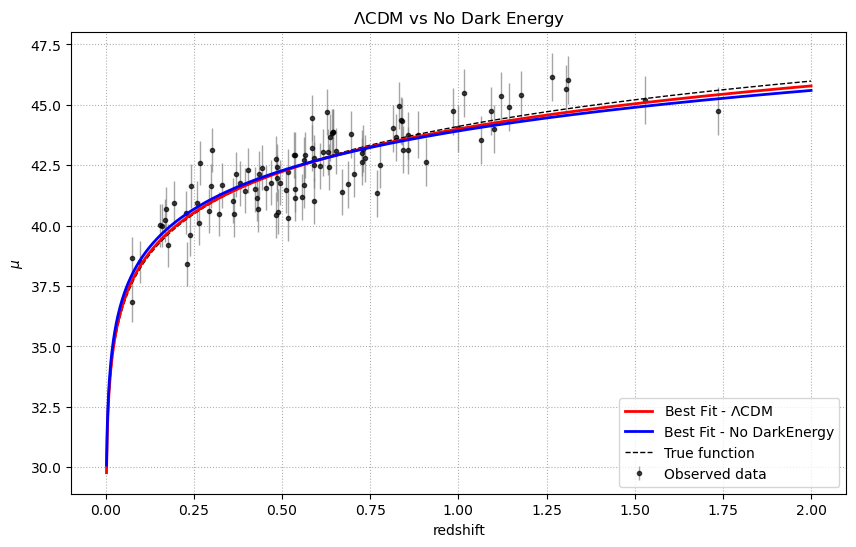

In [56]:
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', alpha=0.7, lw=1, label='Observed data')

plt.plot(z_plot, mu_model_lcdm(z_plot, (H0_mean_lcdm, Om_mean_lcdm)), color='red', lw=2, zorder=10, label=r'Best Fit - $\Lambda$CDM')
plt.plot(z_plot, mu_model_noDE(z_plot, H0_mean), color='blue', lw=2, zorder=10, label='Best Fit - No DarkEnergy')
plt.plot(z_true, mu_true, '--', c='k', label='True function', lw=1)

plt.title(r"$\Lambda$CDM vs No Dark Energy")
plt.xlabel("redshift")
plt.ylabel(r"$\mu$")
plt.grid(linestyle=":")
plt.legend()
plt.show()